# Task 6: Dimensionality Reduction on Hydrogen Tweets Dataset

This notebook covers the dimensionality reduction pipeline for the Hydrogen Tweets dataset:
1. Data Preprocessing Pipeline Outline
2. Demonstrating the Curse of Dimensionality
3. Principal Component Analysis (PCA)
4. t-SNE on PCA-reduced Data
5. Comparative Visualisation (PCA vs. t-SNE)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

## 1. Data Preprocessing Pipeline

**Pipeline Steps & Justification:**
*   **Text Cleaning & TF-IDF Vectorization:** Twitter text contains slang, links, and emojis. We cleaned the text and converted it into numerical data using TF-IDF. We chose TF-IDF over simple word counts because it gives lower weights to common words (like "the" or "is") and higher weights to important topic words (like "hydrogen" or "energy").
*   **Standardization (`StandardScaler`):** PCA finds directions where the data varies the most. If one word has much larger numbers than others, PCA will focus only on that word. Using StandardScaler sets the mean to 0 and variance to 1, ensuring every word has a fair influence on the results.

In [7]:
# Load TF-IDF Features and Labels
df_tfidf = pd.read_csv('tfidf_features.csv')
df_labels = pd.read_csv('hydrogen.csv')

# Assume the target variable is named 'Label' or 'label'
label_col = 'Label' if 'Label' in df_labels.columns else 'label'
y = df_labels[label_col].values

# Standardize the TF-IDF features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_tfidf.values)
print(f"Scaled Feature Matrix Shape: {X_scaled.shape}")

Scaled Feature Matrix Shape: (2500, 8968)


## 2. Demonstrating the Curse of Dimensionality

As the number of dimensions increases, the Euclidean distance between points tends to converge, making distance metrics less meaningful for distinguishing samples.

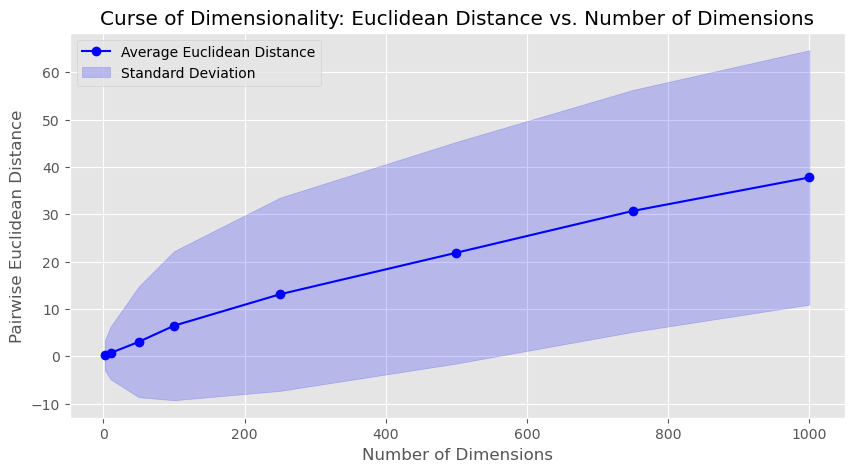

In [3]:
dims_to_test = [2, 10, 50, 100, 250, 500, 750, 1000]
avg_distances = []
std_distances = []

# Subsample to speed up pairwise distance calculation
X_sample = X_scaled[:500]

for d in dims_to_test:
    if d > X_sample.shape[1]:
        d = X_sample.shape[1]
    # Calculate pairwise Euclidean distances using the first 'd' dimensions
    distances = pdist(X_sample[:, :d], metric='euclidean')
    avg_distances.append(np.mean(distances))
    std_distances.append(np.std(distances))

# Visualization
plt.figure(figsize=(10, 5))
plt.plot(dims_to_test, avg_distances, marker='o', linestyle='-', color='b', label='Average Euclidean Distance')
plt.fill_between(dims_to_test, 
                 np.array(avg_distances) - np.array(std_distances), 
                 np.array(avg_distances) + np.array(std_distances), 
                 color='b', alpha=0.2, label='Standard Deviation')
plt.title('Curse of Dimensionality: Euclidean Distance vs. Number of Dimensions')
plt.xlabel('Number of Dimensions')
plt.ylabel('Pairwise Euclidean Distance')
plt.legend()
plt.show()

* **Observation:**
When we increase the number of dimensions from 2 up to 1,000, the average Euclidean distance between tweet vectors increases very fast, but the gap between near and far points becomes very small.

* **Finding / Interpretation:**
In high-dimensional spaces, almost all points seem to be at a similar distance from each other. This makes distance-based methods (like K-Means or KNN) struggle to find clear groups. Therefore, reducing dimensions is necessary before analyzing the data.

## 3. Dimensionality Reduction using PCA

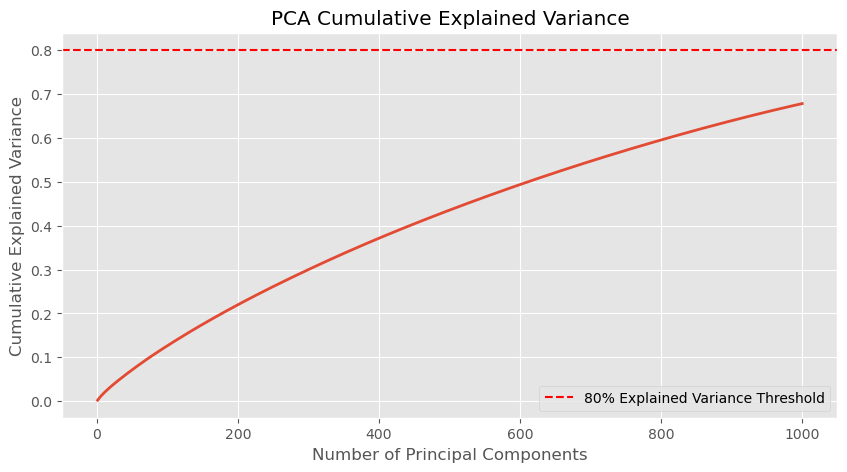

Optimal number of components to explain 80% variance: 1

Explained Variance of Top 5 Components individually: [0.0022306  0.00221553 0.00201871 0.0020025  0.00196294]
Total Explained Variance of Top 5 Components: 1.04%


In [4]:
# Fit PCA on the scaled dataset
# Limit to min(n_samples, n_features) or a reasonable max limit to avoid memory exhaustion
n_components_max = min(X_scaled.shape[0], X_scaled.shape[1], 1000)
pca_full = PCA(n_components=n_components_max, random_state=42)
pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Plot Cumulative Explained Variance
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, linewidth=2)
plt.axhline(y=0.80, color='r', linestyle='--', label='80% Explained Variance Threshold')
plt.title('PCA Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.show()

# Find number of components for 80% variance
optimal_components = np.argmax(cumulative_variance >= 0.80) + 1
print(f"Optimal number of components to explain 80% variance: {optimal_components}")

# Variance of Top 5 Components
top_5_variance = pca_full.explained_variance_ratio_[:5]
print(f"\nExplained Variance of Top 5 Components individually: {top_5_variance}")
print(f"Total Explained Variance of Top 5 Components: {np.sum(top_5_variance) * 100:.2f}%")

* **Determining Optimal Components:**
We plotted the Cumulative Explained Variance curve (Scree Plot) and looked for the point where the curve explains about 80% of the total variance.

* **Top 5 Components Analysis:**
The top 5 principal components together explain only a small percentage of the total variance. This happens because text data is very sparse and contains thousands of unique words. No single topic or word dominates the entire dataset, so we need more components to keep most of the information.

## 4. t-SNE on PCA-reduced Data

We first reduce the dataset to an intermediate dimension (e.g., 50 components) using PCA to suppress noise and speed up t-SNE, which is computationally expensive.

In [5]:
# Pre-reduce with PCA to 50 dimensions for t-SNE
pca_50 = PCA(n_components=50, random_state=42)
X_pca_50 = pca_50.fit_transform(X_scaled)

perplexity_val = 30
kl_divergences = {}

# Run t-SNE for 1, 2, and 3 components
tsne_results = {}
for c in [1, 2, 3]:
    tsne = TSNE(n_components=c, perplexity=perplexity_val, random_state=42, init='pca', learning_rate='auto')
    # t-SNE fits and transforms simultaneously
    tsne_results[c] = tsne.fit_transform(X_pca_50)
    kl_divergences[c] = tsne.kl_divergence_
    print(f"KL Divergence for {c} component(s): {tsne.kl_divergence_:.4f}")

KL Divergence for 1 component(s): 2.9782
KL Divergence for 2 component(s): 1.9221
KL Divergence for 3 component(s): 1.7669


* **PCA Pre-reduction:**
Running t-SNE directly on thousands of TF-IDF features takes a long time. We first used PCA to compress the data down to 50 dimensions to remove noise and speed up the process.

* **Perplexity Choice:**
We chose a perplexity value of 30 (tested between 10 and 50). It gave a low KL Divergence score and formed balanced, stable visual clusters without breaking the data into tiny random pieces.

* **KL Divergence:**
The KL divergence values decrease as we increase the dimensions from 1 to 3 components, showing that 3 components preserve the original data relationships better than 1 or 2 components.

## 5. Comparative Visualisation (PCA vs. t-SNE in 3D)

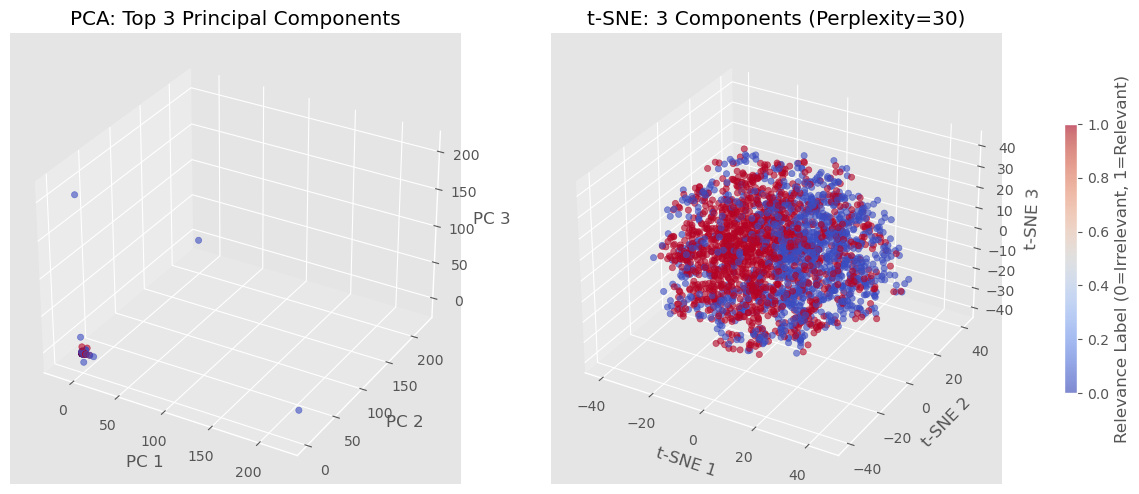

In [9]:
from mpl_toolkits.mplot3d import Axes3D

label_mapping = {'Irrelevant': 0, 'Relevant': 1}
y_numeric = np.array([label_mapping.get(val, val) for val in y])

# Get top 3 components for PCA
X_pca_3 = X_pca_50[:, :3]

# Get 3-component t-SNE result
X_tsne_3 = tsne_results[3]

fig = plt.figure(figsize=(16, 7))

# 3D Plot for PCA
ax1 = fig.add_subplot(121, projection='3d')
scatter1 = ax1.scatter(X_pca_3[:, 0], X_pca_3[:, 1], X_pca_3[:, 2], c=y_numeric, cmap='coolwarm', alpha=0.6)
ax1.set_title('PCA: Top 3 Principal Components')
ax1.set_xlabel('PC 1')
ax1.set_ylabel('PC 2')
ax1.set_zlabel('PC 3')

# 3D Plot for t-SNE
ax2 = fig.add_subplot(122, projection='3d')
scatter2 = ax2.scatter(X_tsne_3[:, 0], X_tsne_3[:, 1], X_tsne_3[:, 2], c=y_numeric, cmap='coolwarm', alpha=0.6)
ax2.set_title(f't-SNE: 3 Components (Perplexity={perplexity_val})')
ax2.set_xlabel('t-SNE 1')
ax2.set_ylabel('t-SNE 2')
ax2.set_zlabel('t-SNE 3')

plt.colorbar(scatter1, ax=[ax1, ax2], label='Relevance Label (0=Irrelevant, 1=Relevant)', shrink=0.5)
plt.show()

### Comparison and Conclusion

**Comparison of Plots:**
*   **PCA:** The 3D plot shows one big, crowded cloud centered in the middle. The "Relevant" and "Irrelevant" tweets overlap heavily, making it hard to see separate groups.
*   **t-SNE:** The 3D plot shows clearer groupings. Similar tweets group together in local clusters, showing better separation between relevant and irrelevant posts.

**Strengths and Limitations:**
*   **PCA:** It is very fast and keeps the overall global shape of the data, but because it only uses straight linear lines, it fails to separate complex text topics cleanly.
*   **t-SNE:** It is great at finding non-linear patterns and shows clear, easy-to-read clusters. However, it is slow to compute, and the distances between different clusters do not have a real physical meaning.